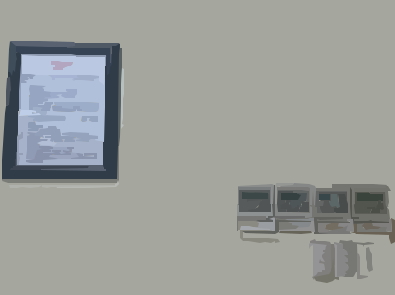

In [1]:
from IPython.display import display, SVG

svg_path = "/home/anhndt/animating_image/output.svg"
with open(svg_path, "r") as f:
    svg = f.read()

display(SVG(svg))

In [2]:
from svgpathtools import svg2paths

def path_to_polygon(path):
    pts = []
    for segment in path:
        # start point
        start = segment.start
        pts.append((start.real, start.imag))
    # add last end point
    pts.append((segment.end.real, segment.end.imag))
    return pts

paths, attrs = svg2paths(svg_path)

polygons = [path_to_polygon(p) for p in paths]

for poly in polygons:
    print(poly)

[(117.0, 44.0), (120.0, 44.0), (118.0, 179.0), (117.0, 180.0), (3.0, 180.0), (2.0, 179.0), (2.0, 160.0), (5.0, 113.0), (6.0, 106.0), (8.0, 105.0), (9.0, 92.0), (10.0, 88.0), (10.0, 84.0), (8.0, 87.0), (8.0, 72.0), (14.0, 69.0), (16.0, 56.0), (16.0, 53.0), (19.0, 51.0), (21.0, 53.0), (21.0, 80.0), (19.0, 111.0), (17.0, 152.0), (15.0, 166.0), (13.0, 166.0), (13.0, 168.0), (11.0, 169.0), (102.0, 170.0), (106.0, 171.0), (106.0, 169.0), (104.0, 169.0), (103.0, 167.0), (103.0, 142.0), (105.0, 66.0), (106.0, 57.0), (107.0, 57.0), (108.0, 74.0), (109.0, 67.0), (111.0, 64.0), (112.0, 46.0), (117.0, 44.0)]
[(104.0, 73.0), (105.0, 73.0), (105.0, 107.0), (104.0, 142.0), (94.0, 141.0), (93.0, 139.0), (98.0, 139.0), (98.0, 136.0), (83.0, 136.0), (84.0, 134.0), (89.0, 135.0), (89.0, 133.0), (81.0, 134.0), (70.0, 133.0), (62.0, 133.0), (62.0, 135.0), (69.0, 135.0), (69.0, 136.0), (61.0, 137.0), (60.0, 135.0), (61.0, 133.0), (59.0, 132.0), (60.0, 129.0), (57.0, 129.0), (56.0, 127.0), (48.0, 126.0), (48

In [3]:
from svgpathtools import svg2paths
import numpy as np


def extract_topk_polygons(svg_path, top_k=10, samples_per_curve=20):
    # --- Convert segment (line/curve) -> list points ---
    def segment_to_points(seg, n=samples_per_curve):
        return [(seg.point(t).real, seg.point(t).imag) 
                for t in np.linspace(0, 1, n)]

    # --- Convert one SVG path -> polygon ---
    def path_to_polygon(path):
        pts = []
        for seg in path:
            pts.extend(segment_to_points(seg))
        return pts

    # --- Shoelace polygon area ---
    def polygon_area(points):
        if len(points) < 3:
            return 0.0
        area = 0
        for i in range(len(points)):
            x1, y1 = points[i]
            x2, y2 = points[(i + 1) % len(points)]
            area += x1 * y2 - x2 * y1
        return abs(area) / 2

    # ---- Parse SVG paths ----
    paths, attributes = svg2paths(svg_path)

    # Convert all to polygons + compute area
    poly_area_pairs = []
    for p in paths:
        poly = path_to_polygon(p)
        area = polygon_area(poly)
        poly_area_pairs.append((area, poly))

    # Sort theo diện tích giảm dần
    poly_area_pairs.sort(key=lambda x: x[0], reverse=True)

    # Lấy top K polygon (chỉ trả về polygon)
    return [poly for (area, poly) in poly_area_pairs[:top_k]]


In [4]:
import json

def polygons_to_json_object(polygons, default_name="unknown"):
    """
    Convert list of polygons → JSON array of objects.
    Mỗi polygon: [(x,y), (x,y), ...]
    Output: list object phù hợp để json.dumps.
    """
    json_list = []

    for poly in polygons:
        obj = {
            "name": default_name,
            "polygon": [[float(x), float(y)] for (x, y) in poly]
        }
        json_list.append(obj)

    return json_list

In [5]:
def restore_polygon_to_image_coords(polygon, svg_w, svg_h, img_w, img_h):
    scale_x = img_w / svg_w
    scale_y = img_h / svg_h

    restored = [
        [x * scale_x, y * scale_y]
        for (x, y) in polygon
    ]
    return restored


In [6]:
polys = extract_topk_polygons(svg_path, top_k=30)
print(len(polys))

# scale về hệ tọa độ ảnh gốc
restored = [
    restore_polygon_to_image_coords(poly, 395, 295, 1276, 956)
    for poly in polys
]
print(len(restored))

# convert toàn bộ polygon sang JSON
json_objects = polygons_to_json_object(restored[1:])
print(len(json_objects))

# ghi file
json_str = json.dumps(json_objects, indent=4)

with open("detected_objects.json", 'w+') as f:
    f.write(json_str)


30
30
29
